# 07_fire_non_fire_comparison.ipynb
**RQ3:** Vergleich von Woody Cover-Trajektorien zwischen Feuer- und Nicht-Feuer-Pixeln  
Alle EEA-Ökoregionen | Covariate Matching | SOM + k-Medoids Clustering

## Method: Fire vs. Non-Fire Trajectory Comparison (07)

**Study area & pixel categorization**
- All EEA ecoregions; pixels classified as *fire* (≥1 burn event 2000–2025) or *non-fire* (no burn record)

**Feature extraction – fire pixels**
- Woody cover trajectories extracted for relative years −5 to +10 around the first fire event (Hansen/Potapov 1985–2024)
- 10 features computed per pixel:
  - Pre-fire mean WC, pre-fire trend (linear slope, 5 yr)
  - Absolute fire loss, relative fire loss (% of WC(−1))
  - Absolute recovery after 1/3/5/10 years — relative to fire-year WC(0)
  - 5-year recovery rate: % of fire loss recovered after 5 years (only where fire loss ≥ 5 %-points, otherwise NaN)
  - 10-year gap to pre-fire baseline: WC(+10) − pre_fire_mean (negative = incomplete recovery)
- *Note:* Pixels with fire year > 2015 lack valid WC(+10) data (woody cover series ends 2024) and are excluded from the analysis.

**Covariate matching**
- 1:1 nearest-neighbor matching (Euclidean distance) of non-fire pixels to each fire pixel, based on pre-fire mean and pre-fire trend (both standardized prior to matching)
- Matched non-fire trajectories are temporally anchored to the fire year of their matched partner — ensuring a comparable observation window

**Clustering (fire pixels only)**
- Feature matrix standardized (z-score); dimensionality reduction via Self-Organizing Map (SOM, PCA-initialized)
- k-Medoids clustering on SOM codebook; optimal k selected via Silhouette Score (k = 2–8 tested)
- Each matched non-fire pixel inherits the cluster label of its fire partner

**Statistical comparison**
- Per cluster, two Mann-Whitney U tests:
  1. 5-year recovery rate (% of loss recovered) — fire vs. matched control
  2. 10-year gap to pre-fire baseline (WC(+10) − pre_fire_mean) — fire vs. matched control
- Effect direction reported as median values (fire vs. control)

---

**Key difference from F2 (bootstrap approach in `05_analysis_eco_lc`):**

| | F2 (bootstrapped null) | 07 (covariate matching) |
|---|---|---|
| Question | Do fire pixels have atypical pre-fire cover? | Do fire pixels recover differently than structurally similar unburned pixels? |
| Temporal focus | Static pre-fire distribution | Full −5 to +10 yr trajectory |
| Control group | 999× resampled, group-level | 1:1 matched, pixel-level |
| Output | Histogram comparison per ecoregion | Cluster-level trajectory + Mann-Whitney test |

In [18]:
# =============================================================================
# 1. Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import os
import time
from tqdm import tqdm
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import mannwhitneyu
from minisom import MiniSom


In [9]:
# =============================================================================
# 2. Pfade & Daten laden
# =============================================================================

_workDir_local  = r"D:\Seafile\Meine Bibliothek\uni\master\thesis"
workDir = _workDir_local
combined_path         = os.path.join(workDir, r"_Runs/05_Landcover_integrated/woody_burned_MBA_MODIS_IGBP_combined.tif")
ecoregion_raster_path = os.path.join(workDir, r"_Runs\03_Ecoregions_EEA\ecoregions_500m_3035_MBA.tif")
ecoregion_attr_path   = os.path.join(workDir, r"_Runs\03_Ecoregions_EEA\ecoregions_attributes_with_colors.csv")
out_base_dir = os.path.join(workDir, "_Runs", "07_Fire_non_Fire_comparison")
os.makedirs(out_base_dir, exist_ok=True)

# === Band-Konfiguration ===
years_woody  = list(range(1985, 2025))   # 40 Bänder
years_burned = list(range(2000, 2026))   # 26 Jahre
WOODY_START  = 1
MBA_START    = len(years_woody) + 1

# === Daten laden ===
print("Lade Woody Cover...")
with rasterio.open(combined_path) as src:
    woody     = src.read(list(range(WOODY_START, WOODY_START + len(years_woody))))
    nodata    = src.nodata
    transform = src.transform
    crs       = src.crs
    height, width = src.height, src.width
    meta      = src.meta.copy()

print("Lade Burned Area...")
with rasterio.open(combined_path) as src:
    burned = src.read([MBA_START + i * 12 for i in range(len(years_burned))])

print("Lade Ecoregion-Raster...")
with rasterio.open(ecoregion_raster_path) as src:
    eco_raster = src.read(1)

ecoregion_df = pd.read_csv(ecoregion_attr_path)
eco_mapping = {
    int(row['NUMERIC_ID']): {
        'code': row['code'], 'name': row['name'], 'hex_color': row['hex_color']
    }
    for _, row in ecoregion_df.iterrows()
}

# === Einmalige Vorberechnungen ===
fire_counts     = np.sum(burned == 1, axis=0)
first_fire_idx  = np.argmax(burned == 1, axis=0)
offset          = years_burned[0] - years_woody[0]   # = 15
rel_years_range = list(range(-5, 11))                 # 16 Relativjahre
x_trend         = np.arange(5, dtype=np.float32)

print(f"\n✓ Alle Daten geladen! Raster: {height}×{width}")
print(f"  Pixel mit ≥1 Brand: {(fire_counts > 0).sum():,}")
print(f"  Ökoregionen: {len(eco_mapping)}")


Lade Woody Cover...
Lade Burned Area...
Lade Ecoregion-Raster...

✓ Alle Daten geladen! Raster: 9660×10483
  Pixel mit ≥1 Brand: 4,301,671
  Ökoregionen: 11


In [11]:
# =============================================================================
# 3. Analyse-Konfiguration
# =============================================================================

ECO_IDS_TO_ANALYSE = list(eco_mapping.keys())  # alle Ökoregionen; oder z.B. [MED_ID] für Test
MIN_FIRE_PIXELS    = 200       # Mindest-Pixel pro Ökoregion (nach NaN-Filter)
K_RANGE            = range(2, 9)
N_SOM_ITERATIONS   = 30000
MAX_TRAIN_PIXELS   = 200000   # Subsample für SOM-Training bei großen Ökoregionen

# 10 Features:
#   [0] pre_fire_mean        — Mittlerer WC Jahre -5 bis -1
#   [1] pre_fire_trend       — Lineare Steigung über Jahre -5 bis -1
#   [2] fire_loss            — WC(-1) - WC(0), absoluter Verlust
#   [3] fire_loss_pct        — Relativer Verlust (% von WC(-1))
#   [4] recovery_1yr         — WC(+1) - WC(0)
#   [5] recovery_3yr         — WC(+3) - WC(0)
#   [6] recovery_5yr         — WC(+5) - WC(0)
#   [7] recovery_10yr        — WC(+10) - WC(0)
#   [8] recovery_rate_5yr    — % Verlust erholt nach 5 J (NaN wenn fire_loss < 5)
#   [9] gap_to_baseline_10yr — WC(+10) - pre_fire_mean (negativ = Lücke zur Baseline)
FEATURE_NAMES = [
    'pre_fire_mean', 'pre_fire_trend',
    'fire_loss', 'fire_loss_pct',
    'recovery_1yr', 'recovery_3yr', 'recovery_5yr', 'recovery_10yr',
    'recovery_rate_5yr', 'gap_to_baseline_10yr'
]

print(f"Analysiere {len(ECO_IDS_TO_ANALYSE)} Ökoregionen")
print(f"k-Range: {list(K_RANGE)}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

Analysiere 11 Ökoregionen
k-Range: [2, 3, 4, 5, 6, 7, 8]
Features (10): ['pre_fire_mean', 'pre_fire_trend', 'fire_loss', 'fire_loss_pct', 'recovery_1yr', 'recovery_3yr', 'recovery_5yr', 'recovery_10yr', 'recovery_rate_5yr', 'gap_to_baseline_10yr']


In [12]:
# =============================================================================
# 4. Helper-Funktionen
# =============================================================================

def extract_fire_features(y, x, fire_idx_arr):
    """
    Extrahiert Trajektorien (-5 bis +10 Jahre relativ zum Brand) und 10 Features
    für Feuer-Pixel. Gibt (trajectories [n,16], feature_matrix [n,10]) zurück.
    Pixel mit fire_idx > 15 (Brand nach 2015) haben NaN für recovery_10yr und
    gap_to_baseline_10yr, da WC-Daten nur bis 2024 vorliegen.
    """
    n     = len(y)
    trajs = np.full((n, len(rel_years_range)), np.nan, dtype=np.float32)

    for j, rel_year in enumerate(rel_years_range):
        band_idx = fire_idx_arr + rel_year + offset - 1
        valid = (band_idx >= 0) & (band_idx < len(years_woody))
        if valid.any():
            vals = woody[band_idx[valid], y[valid], x[valid]].astype(np.float32)
            vals[vals == nodata] = np.nan
            trajs[valid, j] = vals

    pre  = trajs[:, 0:5]   # Relativjahre -5 bis -1
    ym1  = trajs[:, 4]     # Jahr vor Brand (rel -1)
    y0   = trajs[:, 5]     # Brandjahr (rel 0)
    yp1  = trajs[:, 6]
    yp3  = trajs[:, 8]
    yp5  = trajs[:, 10]
    yp10 = trajs[:, 15]    # rel +10

    pre_mean  = np.nanmean(pre, axis=1)
    pre_trend = np.full(n, np.nan, dtype=np.float32)
    for i in range(n):
        v, m = pre[i], ~np.isnan(pre[i])
        if m.sum() >= 3:
            pre_trend[i] = stats.linregress(x_trend[m], v[m])[0]

    with np.errstate(divide='ignore', invalid='ignore'):
        fire_loss     = ym1 - y0
        fire_loss_pct = np.where(ym1 > 0, fire_loss / ym1 * 100, np.nan)
        rec1          = yp1 - y0
        rec3          = yp3 - y0
        rec5          = yp5 - y0
        rec10         = yp10 - y0
        # Normierte Rate nur bei klar messbarem Verlust (≥ 5 %-Punkte), sonst NaN
        rec_rate5     = np.where(fire_loss >= 5, rec5 / fire_loss * 100, np.nan)
        # Gap zur Pre-Fire-Baseline: negativ = nicht erholt, positiv = übertroffen
        gap_baseline  = yp10 - pre_mean

    feats = np.column_stack([pre_mean, pre_trend, fire_loss, fire_loss_pct,
                              rec1, rec3, rec5, rec10,
                              rec_rate5, gap_baseline])
    return trajs, feats


def extract_nofire_matching_features(y, x):
    """
    Extrahiert pre_fire_mean und pre_fire_trend für Nicht-Feuer-Pixel
    über ein festes Fenster (Bänder 16–20, Jahre 2001–2005).
    Gibt (pre_mean [n], pre_trend [n]) zurück.
    """
    pre = woody[16:21, :, :][:, y, x].T.astype(np.float32)  # (n, 5)
    pre[pre == nodata] = np.nan

    pre_mean  = np.nanmean(pre, axis=1)
    pre_trend = np.full(len(y), np.nan, dtype=np.float32)
    for i in range(len(y)):
        v, m = pre[i], ~np.isnan(pre[i])
        if m.sum() >= 3:
            pre_trend[i] = stats.linregress(x_trend[m], v[m])[0]
    return pre_mean, pre_trend


def extract_nofire_trajectories_anchored(y, x, pseudo_fire_idx_arr):
    """
    Extrahiert Trajektorien für Nicht-Feuer-Pixel, zeitlich auf das Brandjahr
    des jeweilig gematchten Feuer-Pixels zentriert (Zeitanker-Fix).
    """
    n     = len(y)
    trajs = np.full((n, len(rel_years_range)), np.nan, dtype=np.float32)

    for j, rel_year in enumerate(rel_years_range):
        band_idx = pseudo_fire_idx_arr + rel_year + offset - 1
        valid = (band_idx >= 0) & (band_idx < len(years_woody))
        if valid.any():
            vals = woody[band_idx[valid], y[valid], x[valid]].astype(np.float32)
            vals[vals == nodata] = np.nan
            trajs[valid, j] = vals
    return trajs

print("✓ Helper-Funktionen definiert")

✓ Helper-Funktionen definiert


In [ ]:
# =============================================================================
# 5. Analyse-Funktion pro Ökoregion
# =============================================================================

def analyse_ecoregion(eco_id, eco_code, eco_name, eco_out_dir):
    """Vollständige Fire-vs-NonFire-Analyse für eine Ökoregion."""

    # ── Masken ───────────────────────────────────────────────────────────────
    eco_mask     = (eco_raster == eco_id)
    fire_mask    = eco_mask & (fire_counts > 0)
    no_fire_mask = eco_mask & (fire_counts == 0)
    n_fire    = int(fire_mask.sum())
    n_no_fire = int(no_fire_mask.sum())
    print(f"  Pixel mit Feuer: {n_fire:,}  |  ohne Feuer: {n_no_fire:,}")

    if n_fire < MIN_FIRE_PIXELS or n_no_fire < MIN_FIRE_PIXELS:
        print(f"  → Übersprungen (zu wenig Pixel)")
        return {'status': 'skipped_count'}

    y_fire,    x_fire    = np.where(fire_mask)
    y_no_fire, x_no_fire = np.where(no_fire_mask)
    fire_idx_arr = first_fire_idx[y_fire, x_fire]

    # ── Feature-Extraktion: Feuer-Pixel ──────────────────────────────────────
    print("  Extrahiere Feuer-Trajektorien & Features...")
    trajs_fire, feats_fire = extract_fire_features(y_fire, x_fire, fire_idx_arr)

    n_pre_filter = n_fire
    # Nur Kern-Features [0:8] müssen vollständig sein; [8] rec_rate5 und [9] gap10 dürfen NaN sein
    valid_mask       = ~np.isnan(feats_fire[:, :8]).any(axis=1)
    feats_fire_clean = feats_fire[valid_mask]
    trajs_fire_clean = trajs_fire[valid_mask]
    y_fire_v         = y_fire[valid_mask]
    x_fire_v         = x_fire[valid_mask]
    fire_idx_v       = fire_idx_arr[valid_mask]
    n_valid_fire     = len(y_fire_v)
    n_dropped_10yr   = int((fire_idx_arr > 15).sum())
    print(f"  ✓ Gültige Feuer-Pixel: {n_valid_fire:,} ({n_valid_fire/n_fire*100:.1f}%)")
    print(f"    (davon {n_dropped_10yr:,} Pixel ohne WC(+10)-Daten, Brand nach 2015)")

    if n_valid_fire < MIN_FIRE_PIXELS:
        print(f"  → Übersprungen (zu wenig gültige Feuer-Pixel nach NaN-Filter)")
        return {'status': 'skipped_nan'}

    # ── Feature-Extraktion: Nicht-Feuer-Pixel (für Matching) ─────────────────
    print("  Extrahiere Nicht-Feuer-Features für Matching...")
    nf_mean, nf_trend = extract_nofire_matching_features(y_no_fire, x_no_fire)

    # BUG FIX 1: Nur pre_fire_mean + pre_fire_trend auf NaN prüfen
    valid_nf       = ~np.isnan(nf_mean) & ~np.isnan(nf_trend)
    nf_mean_clean  = nf_mean[valid_nf]
    nf_trend_clean = nf_trend[valid_nf]
    y_nf_v         = y_no_fire[valid_nf]
    x_nf_v         = x_no_fire[valid_nf]
    n_valid_nf     = len(y_nf_v)
    print(f"  ✓ Gültige Nicht-Feuer-Pixel: {n_valid_nf:,}")

    # ── Covariate Matching (standardisiert, 1:1 NN) ──────────────────────────
    # BUG FIX 2: Standardisieren vor Matching (pre_fire_mean 0–100 vs. trend ~-1–1)
    print("  Covariate Matching...")
    X_fire_match = feats_fire_clean[:, [0, 1]]
    X_nf_match   = np.column_stack([nf_mean_clean, nf_trend_clean])

    match_scaler  = StandardScaler()
    X_fire_scaled = match_scaler.fit_transform(X_fire_match)
    X_nf_scaled   = match_scaler.transform(X_nf_match)

    nbrs        = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(X_nf_scaled)
    _, indices  = nbrs.kneighbors(X_fire_scaled)
    matched_idx = indices.flatten()

    y_matched    = y_nf_v[matched_idx]
    x_matched    = x_nf_v[matched_idx]
    # Pre-Fire-Mittelwert des jeweiligen Kontroll-Pixels (für gap_to_baseline)
    ctrl_premean = nf_mean_clean[matched_idx]   # shape (n_valid_fire,)

    # ── Nicht-Feuer-Trajektorien (zeitlich auf Brand-Jahr geankert) ───────────
    # BUG FIX 3: Pseudo-Brandjahr = Brandjahr des gematchten Feuer-Pixels
    print("  Extrahiere Nicht-Feuer-Trajektorien (zeitlich geankert)...")
    trajs_matched = extract_nofire_trajectories_anchored(y_matched, x_matched, fire_idx_v)

    # ── SOM + k-Medoids Clustering (auf Feuer-Features) ──────────────────────
    print("  SOM-Training...")
    cluster_scaler = StandardScaler()
    feats_scaled   = cluster_scaler.fit_transform(feats_fire_clean)
    n_pix          = n_valid_fire

    som_side = max(10, min(25, int(np.ceil(5 * np.sqrt(n_pix) ** 0.5))))
    som = MiniSom(
        som_side, som_side, feats_scaled.shape[1],
        sigma=max(1.0, som_side / 4), learning_rate=0.5,
        neighborhood_function='gaussian', random_seed=42
    )
    som.pca_weights_init(feats_scaled)

    t0 = time.time()
    train_data = feats_scaled
    if n_pix > MAX_TRAIN_PIXELS:
        rng_sub    = np.random.default_rng(42)
        train_data = feats_scaled[rng_sub.choice(n_pix, MAX_TRAIN_PIXELS, replace=False)]
    som.train_random(train_data, N_SOM_ITERATIONS, verbose=False)
    print(f"  ✓ SOM fertig ({time.time()-t0:.1f}s), Größe: {som_side}×{som_side}")

    bmu      = np.array([som.winner(v) for v in feats_scaled])
    bmu_flat = bmu[:, 0] * som_side + bmu[:, 1]
    codebook = som.get_weights().reshape(-1, feats_scaled.shape[1])

    # ── Cluster-Validierung ──────────────────────────────────────────────────
    print("  k-Medoids Validierung...")
    rng_eval = np.random.default_rng(42)
    eval_idx = rng_eval.choice(n_pix, min(50000, n_pix), replace=False)
    val_rows = []

    for k in K_RANGE:
        kmed      = KMedoids(n_clusters=k, metric='euclidean', random_state=42, max_iter=300)
        cb_labels = kmed.fit_predict(codebook)
        px_labels = cb_labels[bmu_flat]
        sil = silhouette_score(feats_scaled[eval_idx], px_labels[eval_idx],
                               sample_size=min(10000, len(eval_idx)))
        ch  = calinski_harabasz_score(feats_scaled[eval_idx], px_labels[eval_idx])
        db  = davies_bouldin_score(feats_scaled[eval_idx], px_labels[eval_idx])
        val_rows.append({'k': k, 'silhouette': sil, 'calinski_harabasz': ch,
                         'davies_bouldin': db, 'inertia': kmed.inertia_})

    df_val    = pd.DataFrame(val_rows)
    chosen_k  = int(df_val.loc[df_val['silhouette'].idxmax(), 'k'])
    best_k_db = int(df_val.loc[df_val['davies_bouldin'].idxmin(), 'k'])
    print(f"  Best Silhouette: k={chosen_k}  |  Best Davies-Bouldin: k={best_k_db}  → Verwende k={chosen_k}")
    df_val.to_csv(os.path.join(eco_out_dir, "cluster_validation_results.csv"), index=False)

    # Validierungsplot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col, title in zip(axes.flat,
        ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'inertia'],
        ['Silhouette (↑)', 'Calinski-Harabasz (↑)', 'Davies-Bouldin (↓)', 'Inertia / Elbow (↓)']
    ):
        ax.plot(df_val['k'], df_val[col], 'o-', linewidth=2)
        ax.set_xlabel('k'); ax.set_title(title); ax.grid(True, alpha=0.3)
        ax.axvline(x=chosen_k, color='red', linestyle='--', alpha=0.6, label=f'k={chosen_k}')
        ax.legend(fontsize=8)
    plt.suptitle(f'Cluster Validation – {eco_code}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(eco_out_dir, "cluster_validation_metrics.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── Finale Clusterung ────────────────────────────────────────────────────
    kmed_final      = KMedoids(n_clusters=chosen_k, metric='euclidean', random_state=42, max_iter=300)
    cb_labels_final = kmed_final.fit_predict(codebook)
    cluster_labels  = cb_labels_final[bmu_flat]

    print("  Cluster-Verteilung:")
    for cl, cnt in zip(*np.unique(cluster_labels, return_counts=True)):
        print(f"    Cluster {cl}: {cnt:,} ({cnt/n_pix*100:.1f}%)")

    # ── Trajektorien-Plot ────────────────────────────────────────────────────
    COLORS = plt.cm.Set1(np.linspace(0, 1, chosen_k))
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ax = axes[0]

    for cl in range(chosen_k):
        mask = cluster_labels == cl
        mf   = np.nanmean(trajs_fire_clean[mask], axis=0)
        sf   = np.nanstd(trajs_fire_clean[mask],  axis=0)
        mc   = np.nanmean(trajs_matched[mask],     axis=0)

        ax.plot(rel_years_range, mf, '-o', color=COLORS[cl], linewidth=2.5,
                label=f'C{cl} Feuer (n={mask.sum():,})')
        ax.fill_between(rel_years_range, np.maximum(mf - sf, 0), np.minimum(mf + sf, 100),
                        alpha=0.12, color=COLORS[cl])
        ax.plot(rel_years_range, mc, '--', color=COLORS[cl], linewidth=1.5, alpha=0.55,
                label=f'C{cl} Kontrolle')

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Brandjahr')
    ax.set_xlabel('Jahre relativ zum Brand', fontsize=11)
    ax.set_ylabel('Woody Cover (%)', fontsize=11)
    ax.set_title(f'{eco_code} – Feuer (—) vs. Kontrolle (--)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3); ax.set_xlim(-5.5, 10.5)

    ax2 = axes[1]
    cl_means = np.array([np.nanmean(feats_fire_clean[cluster_labels == cl], axis=0)
                         for cl in range(chosen_k)])
    df_cl = pd.DataFrame(cl_means,
                         index=[f'C{cl}' for cl in range(chosen_k)],
                         columns=FEATURE_NAMES)
    sns.heatmap(df_cl, cmap='RdYlGn', annot=True, fmt='.1f', ax=ax2,
                linewidths=0.5, center=0, cbar_kws={'label': 'Mittelwert'})
    ax2.set_title('Cluster Feature-Profile', fontsize=11)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=40, ha='right')

    plt.suptitle(f'{eco_code} | {eco_name}  (k={chosen_k})', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(eco_out_dir, "cluster_trajectories.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── Statistischer Vergleich: Feuer vs. Kontrolle pro Cluster ─────────────
    stat_rows = []
    for cl in range(chosen_k):
        mask = cluster_labels == cl

        # Feuer-Seite (Indizes 8 und 9)
        fire_rec5  = feats_fire_clean[mask, 8]              # recovery_rate_5yr
        fire_gap10 = feats_fire_clean[mask, 9]              # gap_to_baseline_10yr
        fire_rec5  = fire_rec5[~np.isnan(fire_rec5)]
        fire_gap10 = fire_gap10[~np.isnan(fire_gap10)]

        # Kontroll-Seite: recovery_rate_5yr und gap_to_baseline_10yr
        ym1_c  = trajs_matched[mask, 4]
        y0_c   = trajs_matched[mask, 5]
        y5_c   = trajs_matched[mask, 10]
        y10_c  = trajs_matched[mask, 15]
        loss_c = ym1_c - y0_c
        with np.errstate(divide='ignore', invalid='ignore'):
            ctrl_rec5  = np.where(loss_c >= 5, (y5_c - y0_c) / loss_c * 100, np.nan)
            ctrl_gap10 = y10_c - ctrl_premean[mask]
        ctrl_rec5  = ctrl_rec5[~np.isnan(ctrl_rec5)]
        ctrl_gap10 = ctrl_gap10[~np.isnan(ctrl_gap10)]

        p_rec5 = p_gap10 = np.nan
        if len(fire_rec5) > 5 and len(ctrl_rec5) > 5:
            _, p_rec5  = mannwhitneyu(fire_rec5,  ctrl_rec5,  alternative='two-sided')
        if len(fire_gap10) > 5 and len(ctrl_gap10) > 5:
            _, p_gap10 = mannwhitneyu(fire_gap10, ctrl_gap10, alternative='two-sided')

        row = {
            'eco_code': eco_code, 'cluster': cl, 'n_fire': int(mask.sum()),
            'fire_rec5_median':   float(np.nanmedian(fire_rec5))  if len(fire_rec5)  else np.nan,
            'ctrl_rec5_median':   float(np.nanmedian(ctrl_rec5))  if len(ctrl_rec5)  else np.nan,
            'p_rec5':             float(p_rec5),
            'fire_gap10_median':  float(np.nanmedian(fire_gap10)) if len(fire_gap10) else np.nan,
            'ctrl_gap10_median':  float(np.nanmedian(ctrl_gap10)) if len(ctrl_gap10) else np.nan,
            'p_gap10':            float(p_gap10)
        }
        stat_rows.append(row)
        print(f"    C{cl}: rec5yr  Feuer={row['fire_rec5_median']:.1f}%  Ctrl={row['ctrl_rec5_median']:.1f}%  p={p_rec5:.4f}"
              f"  |  gap10yr  Feuer={row['fire_gap10_median']:.1f}  Ctrl={row['ctrl_gap10_median']:.1f}  p={p_gap10:.4f}")

    pd.DataFrame(stat_rows).to_csv(os.path.join(eco_out_dir, "fire_vs_control_stats.csv"), index=False)

    # ── Cluster-Raster exportieren ────────────────────────────────────────────
    cluster_raster_out = np.full((height, width), -1, dtype=np.int16)
    cluster_raster_out[y_fire_v,  x_fire_v]  = cluster_labels
    cluster_raster_out[y_matched, x_matched] = cluster_labels   # 1:1 gleiche Reihenfolge

    raster_meta = meta.copy()
    raster_meta.update(dtype='int16', count=1, nodata=-1)
    with rasterio.open(os.path.join(eco_out_dir, f"cluster_labels_{eco_code}.tif"),
                       'w', **raster_meta) as dst:
        dst.write(cluster_raster_out, 1)

    print(f"  ✓ Fertig: {eco_out_dir}")

    np.savez_compressed(
        os.path.join(eco_out_dir, "cluster_data.npz"),
        feats_fire_clean = feats_fire_clean,   # (n, 10) Features Feuer-Pixel
        trajs_fire_clean = trajs_fire_clean,   # (n, 16) Trajektorien Feuer-Pixel
        trajs_matched    = trajs_matched,      # (n, 16) Trajektorien Kontroll-Pixel
        cluster_labels   = cluster_labels,     # (n,)    Cluster-Zuweisung
        ctrl_premean     = ctrl_premean,       # (n,)    Pre-Fire-Mittelwert Kontrolle
        chosen_k         = np.array([chosen_k])
    )

    return {
        'status': 'ok', 'n_fire': n_fire, 'n_valid_fire': n_valid_fire,
        'n_no_fire': n_no_fire, 'chosen_k': chosen_k,
        'best_sil_k': chosen_k, 'best_db_k': best_k_db
    }

print("✓ analyse_ecoregion() definiert")


In [14]:
# =============================================================================
# 6. Haupt-Schleife über alle Ökoregionen
# =============================================================================

summary_rows = []

for eco_id in ECO_IDS_TO_ANALYSE:
    eco_info    = eco_mapping[eco_id]
    eco_code    = eco_info['code']
    eco_name    = eco_info['name']
    eco_out_dir = os.path.join(out_base_dir, eco_code)
    os.makedirs(eco_out_dir, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  {eco_code} – {eco_name}")
    print(f"{'='*70}")

    result = analyse_ecoregion(eco_id, eco_code, eco_name, eco_out_dir)
    summary_rows.append({'eco_code': eco_code, 'eco_name': eco_name, **result})

print("\n\n✅ ALLE ÖKOREGIONEN ABGESCHLOSSEN!")



  Anatolian – Anatolian Bio-geographical Region
  Pixel mit Feuer: 152,667  |  ohne Feuer: 1,596,601
  Extrahiere Feuer-Trajektorien & Features...
  ✓ Gültige Feuer-Pixel: 532 (0.3%)
    (davon 25,706 Pixel ohne WC(+10)-Daten, Brand nach 2015)
  Extrahiere Nicht-Feuer-Features für Matching...
  ✓ Gültige Nicht-Feuer-Pixel: 1,596,601
  Covariate Matching...
  Extrahiere Nicht-Feuer-Trajektorien (zeitlich geankert)...
  SOM-Training...
  ✓ SOM fertig (3.2s), Größe: 25×25
  k-Medoids Validierung...
  Best Silhouette: k=2  |  Best Davies-Bouldin: k=3  → Verwende k=2
  Cluster-Verteilung:
    Cluster 0: 394 (74.1%)
    Cluster 1: 138 (25.9%)
    C0: rec5yr  Feuer=0.0%  Ctrl=-33.3%  p=nan  |  gap10yr  Feuer=-4.2  Ctrl=0.9  p=0.0000
    C1: rec5yr  Feuer=58.6%  Ctrl=10.0%  p=0.3470  |  gap10yr  Feuer=1.1  Ctrl=2.0  p=0.8718
  ✓ Fertig: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\07_Fire_non_Fire_comparison\Anatolian

  BlackSea – Black Sea Bio-geographical Region
  Pixel mit Feuer: 1

In [15]:
# =============================================================================
# 7. Summary-Export & Übersichtsplot
# =============================================================================

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(os.path.join(out_base_dir, "analysis_summary.csv"), index=False)

print(df_summary[['eco_code', 'status', 'n_fire', 'n_valid_fire', 'chosen_k']].to_string(index=False))

# === Übersichtsplot ===
df_ok = df_summary[df_summary['status'] == 'ok'].copy()

if len(df_ok) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(df_ok['eco_code'], df_ok['n_valid_fire'], color='steelblue')
    axes[0].set_xlabel('Gültige Feuer-Pixel')
    axes[0].set_title('Feuer-Pixel pro Ökoregion')
    axes[0].grid(True, axis='x', alpha=0.3)

    axes[1].bar(df_ok['eco_code'], df_ok['chosen_k'], color='tomato')
    axes[1].set_ylabel('Gewähltes k')
    axes[1].set_title('Optimales k (Silhouette) pro Ökoregion')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.suptitle('Analyse-Übersicht: Fire vs. Non-Fire Comparison', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(out_base_dir, "summary_overview.png"), dpi=150, bbox_inches='tight')
    plt.close()
    print("✓ summary_overview.png gespeichert")

print(f"\n✅ Ergebnisse in: {out_base_dir}")


     eco_code      status    n_fire  n_valid_fire  chosen_k
    Anatolian          ok  152667.0         532.0       2.0
     BlackSea          ok   14433.0         318.0       2.0
      Steppic          ok 1925776.0       41639.0       2.0
  Continental          ok 1106712.0       43538.0       2.0
       Alpine          ok   90576.0        1975.0       3.0
       Boreal          ok  263972.0       12713.0       2.0
Mediterranean          ok  332768.0        8944.0       2.0
    Pannonian          ok   44257.0        1135.0       2.0
     Atlantic          ok   46346.0        1450.0       2.0
      Outside          ok  315224.0       10215.0       2.0
       Arctic skipped_nan       NaN           NaN       NaN
✓ summary_overview.png gespeichert

✅ Ergebnisse in: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\07_Fire_non_Fire_comparison


In [ ]:
# =============================================================================
# 1. Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import os
import time
from tqdm import tqdm
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import mannwhitneyu
from minisom import MiniSom
</VSCode.Cell>

<VSCode.Cell id="#VSC-8743ddde 07_fire_non_fire_comparison.ipynb" language="python">
# =============================================================================
# 3. Analyse-Konfiguration
# =============================================================================

# 'Outside' gehört nicht zur Study Area → explizit ausschließen
ECO_IDS_TO_ANALYSE = [eid for eid, info in eco_mapping.items() if info['code'] != 'Outside']
MIN_FIRE_PIXELS    = 200       # Mindest-Pixel pro Ökoregion (nach NaN-Filter)
K_RANGE            = range(2, 9)
N_SOM_ITERATIONS   = 30000
MAX_TRAIN_PIXELS   = 200000   # Subsample für SOM-Training bei großen Ökoregionen

# 10 Features:
#   [0] pre_fire_mean        — Mittlerer WC Jahre -5 bis -1
#   [1] pre_fire_trend       — Lineare Steigung über Jahre -5 bis -1
#   [2] fire_loss            — WC(-1) - WC(0), absoluter Verlust
#   [3] fire_loss_pct        — Relativer Verlust (% von WC(-1))
#   [4] recovery_1yr         — WC(+1) - WC(0)
#   [5] recovery_3yr         — WC(+3) - WC(0)
#   [6] recovery_5yr         — WC(+5) - WC(0)
#   [7] recovery_10yr        — WC(+10) - WC(0)
#   [8] recovery_rate_5yr    — % Verlust erholt nach 5 J (NaN wenn fire_loss < 5)  → nur Stat-Tests
#   [9] gap_to_baseline_10yr — WC(+10) - pre_fire_mean (negativ = Lücke zur Baseline) → nur Stat-Tests
# Clustering verwendet nur [0:8] (NaN-frei); [8:10] werden für stat. Vergleich genutzt.
FEATURE_NAMES = [
    'pre_fire_mean', 'pre_fire_trend',
    'fire_loss', 'fire_loss_pct',
    'recovery_1yr', 'recovery_3yr', 'recovery_5yr', 'recovery_10yr',
    'recovery_rate_5yr', 'gap_to_baseline_10yr'
]

print(f"Analysiere {len(ECO_IDS_TO_ANALYSE)} Ökoregionen (ohne 'Outside')")
print(f"k-Range: {list(K_RANGE)}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
</VSCode.Cell>

<VSCode.Cell id="#VSC-cf7e6351 07_fire_non_fire_comparison.ipynb" language="python">
# =============================================================================
# 5. Analyse-Funktion pro Ökoregion
# =============================================================================

def analyse_ecoregion(eco_id, eco_code, eco_name, eco_out_dir):
    """Vollständige Fire-vs-NonFire-Analyse für eine Ökoregion."""

    # ── Masken ───────────────────────────────────────────────────────────────
    eco_mask     = (eco_raster == eco_id)
    fire_mask    = eco_mask & (fire_counts > 0)
    no_fire_mask = eco_mask & (fire_counts == 0)
    n_fire    = int(fire_mask.sum())
    n_no_fire = int(no_fire_mask.sum())
    print(f"  Pixel mit Feuer: {n_fire:,}  |  ohne Feuer: {n_no_fire:,}")

    if n_fire < MIN_FIRE_PIXELS or n_no_fire < MIN_FIRE_PIXELS:
        print(f"  → Übersprungen (zu wenig Pixel)")
        return {'status': 'skipped_count'}

    y_fire,    x_fire    = np.where(fire_mask)
    y_no_fire, x_no_fire = np.where(no_fire_mask)
    fire_idx_arr = first_fire_idx[y_fire, x_fire]

    # ── Feature-Extraktion: Feuer-Pixel ──────────────────────────────────────
    print("  Extrahiere Feuer-Trajektorien & Features...")
    trajs_fire, feats_fire = extract_fire_features(y_fire, x_fire, fire_idx_arr)

    # Nur Kern-Features [0:8] müssen vollständig sein;
    # [8] rec_rate5 (NaN wenn fire_loss < 5) und [9] gap10 (NaN wenn Brand > 2015) dürfen NaN sein
    valid_mask       = ~np.isnan(feats_fire[:, :8]).any(axis=1)
    feats_fire_clean = feats_fire[valid_mask]        # (n, 10) — [8:10] können NaN enthalten
    trajs_fire_clean = trajs_fire[valid_mask]
    y_fire_v         = y_fire[valid_mask]
    x_fire_v         = x_fire[valid_mask]
    fire_idx_v       = fire_idx_arr[valid_mask]
    n_valid_fire     = len(y_fire_v)
    n_dropped_10yr   = int((fire_idx_arr > 15).sum())
    print(f"  ✓ Gültige Feuer-Pixel: {n_valid_fire:,} ({n_valid_fire/n_fire*100:.1f}%)")
    print(f"    (davon {n_dropped_10yr:,} Pixel ohne WC(+10)-Daten, Brand nach 2015)")

    if n_valid_fire < MIN_FIRE_PIXELS:
        print(f"  → Übersprungen (zu wenig gültige Feuer-Pixel nach NaN-Filter)")
        return {'status': 'skipped_nan'}

    # ── Feature-Extraktion: Nicht-Feuer-Pixel (für Matching) ─────────────────
    print("  Extrahiere Nicht-Feuer-Features für Matching...")
    nf_mean, nf_trend = extract_nofire_matching_features(y_no_fire, x_no_fire)

    valid_nf       = ~np.isnan(nf_mean) & ~np.isnan(nf_trend)
    nf_mean_clean  = nf_mean[valid_nf]
    nf_trend_clean = nf_trend[valid_nf]
    y_nf_v         = y_no_fire[valid_nf]
    x_nf_v         = x_no_fire[valid_nf]
    n_valid_nf     = len(y_nf_v)
    print(f"  ✓ Gültige Nicht-Feuer-Pixel: {n_valid_nf:,}")

    # ── Covariate Matching (standardisiert, 1:1 NN) ──────────────────────────
    print("  Covariate Matching...")
    X_fire_match = feats_fire_clean[:, [0, 1]]
    X_nf_match   = np.column_stack([nf_mean_clean, nf_trend_clean])

    match_scaler  = StandardScaler()
    X_fire_scaled = match_scaler.fit_transform(X_fire_match)
    X_nf_scaled   = match_scaler.transform(X_nf_match)

    nbrs        = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(X_nf_scaled)
    _, indices  = nbrs.kneighbors(X_fire_scaled)
    matched_idx = indices.flatten()

    y_matched    = y_nf_v[matched_idx]
    x_matched    = x_nf_v[matched_idx]
    ctrl_premean = nf_mean_clean[matched_idx]   # shape (n_valid_fire,)

    # ── Nicht-Feuer-Trajektorien (zeitlich auf Brand-Jahr geankert) ───────────
    print("  Extrahiere Nicht-Feuer-Trajektorien (zeitlich geankert)...")
    trajs_matched = extract_nofire_trajectories_anchored(y_matched, x_matched, fire_idx_v)

    # ── SOM + k-Medoids Clustering (nur auf Kern-Features [0:8]) ─────────────
    # Features [8] und [9] können NaN enthalten → nur [0:8] für Clustering;
    # [8:10] ausschließlich für statistische Tests (intern NaN-gefiltert).
    print("  SOM-Training...")
    cluster_scaler = StandardScaler()
    feats_scaled   = cluster_scaler.fit_transform(feats_fire_clean[:, :8])  # (n, 8), NaN-frei
    n_pix          = n_valid_fire

    som_side = max(10, min(25, int(np.ceil(5 * np.sqrt(n_pix) ** 0.5))))
    som = MiniSom(
        som_side, som_side, feats_scaled.shape[1],
        sigma=max(1.0, som_side / 4), learning_rate=0.5,
        neighborhood_function='gaussian', random_seed=42
    )
    som.pca_weights_init(feats_scaled)

    t0 = time.time()
    train_data = feats_scaled
    if n_pix > MAX_TRAIN_PIXELS:
        rng_sub    = np.random.default_rng(42)
        train_data = feats_scaled[rng_sub.choice(n_pix, MAX_TRAIN_PIXELS, replace=False)]
    som.train_random(train_data, N_SOM_ITERATIONS, verbose=False)
    print(f"  ✓ SOM fertig ({time.time()-t0:.1f}s), Größe: {som_side}×{som_side}")

    codebook = som.get_weights().reshape(-1, feats_scaled.shape[1])  # (som_side², 8)

    # Vektorisierte BMU-Zuordnung via cdist in Chunks (ersetzt langsamen Python-Loop)
    # Chunk-Größe so gewählt, dass Speicherpeak << 1 GB bleibt
    CHUNK    = 10000
    bmu_flat = np.empty(n_pix, dtype=np.int32)
    for _s in range(0, n_pix, CHUNK):
        _e = min(_s + CHUNK, n_pix)
        _d = cdist(feats_scaled[_s:_e], codebook, metric='sqeuclidean')  # (chunk, n_cb)
        bmu_flat[_s:_e] = np.argmin(_d, axis=1)

    # ── Cluster-Validierung ──────────────────────────────────────────────────
    print("  k-Medoids Validierung...")
    rng_eval = np.random.default_rng(42)
    eval_idx = rng_eval.choice(n_pix, min(50000, n_pix), replace=False)
    val_rows = []

    for k in K_RANGE:
        kmed      = KMedoids(n_clusters=k, metric='euclidean', random_state=42, max_iter=300)
        cb_labels = kmed.fit_predict(codebook)
        px_labels = cb_labels[bmu_flat]
        sil = silhouette_score(feats_scaled[eval_idx], px_labels[eval_idx],
                               sample_size=min(10000, len(eval_idx)))
        ch  = calinski_harabasz_score(feats_scaled[eval_idx], px_labels[eval_idx])
        db  = davies_bouldin_score(feats_scaled[eval_idx], px_labels[eval_idx])
        val_rows.append({'k': k, 'silhouette': sil, 'calinski_harabasz': ch,
                         'davies_bouldin': db, 'inertia': kmed.inertia_})

    df_val    = pd.DataFrame(val_rows)
    chosen_k  = int(df_val.loc[df_val['silhouette'].idxmax(), 'k'])
    best_k_db = int(df_val.loc[df_val['davies_bouldin'].idxmin(), 'k'])
    print(f"  Best Silhouette: k={chosen_k}  |  Best Davies-Bouldin: k={best_k_db}  → Verwende k={chosen_k}")
    df_val.to_csv(os.path.join(eco_out_dir, "cluster_validation_results.csv"), index=False)

    # Validierungsplot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, col, title in zip(axes.flat,
        ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'inertia'],
        ['Silhouette (↑)', 'Calinski-Harabasz (↑)', 'Davies-Bouldin (↓)', 'Inertia / Elbow (↓)']
    ):
        ax.plot(df_val['k'], df_val[col], 'o-', linewidth=2)
        ax.set_xlabel('k'); ax.set_title(title); ax.grid(True, alpha=0.3)
        ax.axvline(x=chosen_k, color='red', linestyle='--', alpha=0.6, label=f'k={chosen_k}')
        ax.legend(fontsize=8)
    plt.suptitle(f'Cluster Validation – {eco_code}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(eco_out_dir, "cluster_validation_metrics.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── Finale Clusterung ────────────────────────────────────────────────────
    kmed_final      = KMedoids(n_clusters=chosen_k, metric='euclidean', random_state=42, max_iter=300)
    cb_labels_final = kmed_final.fit_predict(codebook)
    cluster_labels  = cb_labels_final[bmu_flat]

    print("  Cluster-Verteilung:")
    for cl, cnt in zip(*np.unique(cluster_labels, return_counts=True)):
        print(f"    Cluster {cl}: {cnt:,} ({cnt/n_pix*100:.1f}%)")

    # ── Trajektorien-Plot ────────────────────────────────────────────────────
    COLORS = plt.cm.Set1(np.linspace(0, 1, chosen_k))
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ax = axes[0]

    for cl in range(chosen_k):
        mask = cluster_labels == cl
        mf   = np.nanmean(trajs_fire_clean[mask], axis=0)
        sf   = np.nanstd(trajs_fire_clean[mask],  axis=0)
        mc   = np.nanmean(trajs_matched[mask],     axis=0)

        ax.plot(rel_years_range, mf, '-o', color=COLORS[cl], linewidth=2.5,
                label=f'C{cl} Feuer (n={mask.sum():,})')
        ax.fill_between(rel_years_range, np.maximum(mf - sf, 0), np.minimum(mf + sf, 100),
                        alpha=0.12, color=COLORS[cl])
        ax.plot(rel_years_range, mc, '--', color=COLORS[cl], linewidth=1.5, alpha=0.55,
                label=f'C{cl} Kontrolle')

    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Brandjahr')
    ax.set_xlabel('Jahre relativ zum Brand', fontsize=11)
    ax.set_ylabel('Woody Cover (%)', fontsize=11)
    ax.set_title(f'{eco_code} – Feuer (—) vs. Kontrolle (--)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3); ax.set_xlim(-5.5, 10.5)

    ax2 = axes[1]
    # Heatmap über alle 10 Features (nanmean ignoriert NaN in [8:10])
    cl_means = np.array([np.nanmean(feats_fire_clean[cluster_labels == cl], axis=0)
                         for cl in range(chosen_k)])
    df_cl = pd.DataFrame(cl_means,
                         index=[f'C{cl}' for cl in range(chosen_k)],
                         columns=FEATURE_NAMES)
    sns.heatmap(df_cl, cmap='RdYlGn', annot=True, fmt='.1f', ax=ax2,
                linewidths=0.5, center=0, cbar_kws={'label': 'Mittelwert'})
    ax2.set_title('Cluster Feature-Profile', fontsize=11)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=40, ha='right')

    plt.suptitle(f'{eco_code} | {eco_name}  (k={chosen_k})', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(eco_out_dir, "cluster_trajectories.png"), dpi=150, bbox_inches='tight')
    plt.close()

    # ── Statistischer Vergleich: Feuer vs. Kontrolle pro Cluster ─────────────
    stat_rows = []
    for cl in range(chosen_k):
        mask = cluster_labels == cl

        # Feuer-Seite (Indizes 8 und 9) — NaN-Pixel intern herausfiltern
        fire_rec5  = feats_fire_clean[mask, 8]              # recovery_rate_5yr
        fire_gap10 = feats_fire_clean[mask, 9]              # gap_to_baseline_10yr
        fire_rec5  = fire_rec5[~np.isnan(fire_rec5)]
        fire_gap10 = fire_gap10[~np.isnan(fire_gap10)]

        # Kontroll-Seite: recovery_rate_5yr und gap_to_baseline_10yr
        ym1_c  = trajs_matched[mask, 4]
        y0_c   = trajs_matched[mask, 5]
        y5_c   = trajs_matched[mask, 10]
        y10_c  = trajs_matched[mask, 15]
        loss_c = ym1_c - y0_c
        with np.errstate(divide='ignore', invalid='ignore'):
            ctrl_rec5  = np.where(loss_c >= 5, (y5_c - y0_c) / loss_c * 100, np.nan)
            ctrl_gap10 = y10_c - ctrl_premean[mask]
        ctrl_rec5  = ctrl_rec5[~np.isnan(ctrl_rec5)]
        ctrl_gap10 = ctrl_gap10[~np.isnan(ctrl_gap10)]

        p_rec5 = p_gap10 = np.nan
        if len(fire_rec5) > 5 and len(ctrl_rec5) > 5:
            _, p_rec5  = mannwhitneyu(fire_rec5,  ctrl_rec5,  alternative='two-sided')
        if len(fire_gap10) > 5 and len(ctrl_gap10) > 5:
            _, p_gap10 = mannwhitneyu(fire_gap10, ctrl_gap10, alternative='two-sided')

        row = {
            'eco_code': eco_code, 'cluster': cl, 'n_fire': int(mask.sum()),
            'fire_rec5_median':   float(np.nanmedian(fire_rec5))  if len(fire_rec5)  else np.nan,
            'ctrl_rec5_median':   float(np.nanmedian(ctrl_rec5))  if len(ctrl_rec5)  else np.nan,
            'p_rec5':             float(p_rec5),
            'fire_gap10_median':  float(np.nanmedian(fire_gap10)) if len(fire_gap10) else np.nan,
            'ctrl_gap10_median':  float(np.nanmedian(ctrl_gap10)) if len(ctrl_gap10) else np.nan,
            'p_gap10':            float(p_gap10)
        }
        stat_rows.append(row)
        print(f"    C{cl}: rec5yr  Feuer={row['fire_rec5_median']:.1f}%  Ctrl={row['ctrl_rec5_median']:.1f}%  p={p_rec5:.4f}"
              f"  |  gap10yr  Feuer={row['fire_gap10_median']:.1f}  Ctrl={row['ctrl_gap10_median']:.1f}  p={p_gap10:.4f}")

    pd.DataFrame(stat_rows).to_csv(os.path.join(eco_out_dir, "fire_vs_control_stats.csv"), index=False)

    # ── Cluster-Raster exportieren ────────────────────────────────────────────
    cluster_raster_out = np.full((height, width), -1, dtype=np.int16)
    cluster_raster_out[y_fire_v,  x_fire_v]  = cluster_labels
    cluster_raster_out[y_matched, x_matched] = cluster_labels

    raster_meta = meta.copy()
    raster_meta.update(dtype='int16', count=1, nodata=-1)
    with rasterio.open(os.path.join(eco_out_dir, f"cluster_labels_{eco_code}.tif"),
                       'w', **raster_meta) as dst:
        dst.write(cluster_raster_out, 1)

    print(f"  ✓ Fertig: {eco_out_dir}")

    np.savez_compressed(
        os.path.join(eco_out_dir, "cluster_data.npz"),
        feats_fire_clean = feats_fire_clean,
        trajs_fire_clean = trajs_fire_clean,
        trajs_matched    = trajs_matched,
        cluster_labels   = cluster_labels,
        ctrl_premean     = ctrl_premean,
        chosen_k         = np.array([chosen_k])
    )

    return {
        'status': 'ok', 'n_fire': n_fire, 'n_valid_fire': n_valid_fire,
        'n_no_fire': n_no_fire, 'chosen_k': chosen_k,
        'best_sil_k': chosen_k, 'best_db_k': best_k_db
    }

print("✓ analyse_ecoregion() definiert")


Drei Änderungen zusammengefasst:

- **Cell 1**: `from scipy.spatial.distance import cdist` hinzugefügt
- **Cell 3**: `ECO_IDS_TO_ANALYSE` filtert jetzt `code != 'Outside'` heraus (10 → 9 Ökoregionen)
- **Cell 5**: BMU-Schleife ersetzt durch `cdist` in 10k-Chunks — läuft für 1,9M Pixel in Sekunden statt Stunden. Außerdem bleibt der SOM auf Features `[:, :8]` beschränkt.

# 8. Compact Multi-Ecoregion Summary + LC Proportions per Cluster

Loads cluster label rasters, MODIS IGBP land cover, and (if available) cached `.npz`
trajectory / feature data.  Produces:

1. **Cluster LC proportions** – for every ecoregion × cluster the share of each IGBP major land-cover class among fire pixels.
2. **Compact summary figure** – trajectories, feature-profile heat-map, and LC stacked bars for selected ecoregions side by side.
3. **CSV export** – `cluster_lc_proportions.csv`

In [3]:
# =============================================================================
# 8a. Load cluster labels, MODIS IGBP, compute LC proportions + trajectories
# =============================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import rasterio, os, pathlib

# --- paths (self-contained so this cell works independently) ----------------
_workDir  = r"D:\Seafile\Meine Bibliothek\uni\master\thesis"
_out_base = os.path.join(_workDir, "_Runs", "07_Fire_non_Fire_comparison")
_modis_path = os.path.join(_workDir,
    r"_Runs\04_Landcover\MODIS_GEE_tiles\MODIS_IGBP_2001_2024_500m_wildE.tif")
_combined_path = os.path.join(_workDir,
    r"_Runs/05_Landcover_integrated/woody_burned_MBA_MODIS_IGBP_combined.tif")
_eco_raster_path = os.path.join(_workDir,
    r"_Runs\03_Ecoregions_EEA\ecoregions_500m_3035_MBA.tif")
_eco_attr_path = os.path.join(_workDir,
    r"_Runs\03_Ecoregions_EEA\ecoregions_attributes_with_colors.csv")

# --- IGBP mapping (18 IGBP → 11 major LC) ----------------------------------
igbp_to_major = np.array(
    [0, 1, 1, 1, 1, 1, 2, 2, 3, 3, 4, 5, 6, 7, 6, 8, 8, 9], dtype=np.uint8)
MAJOR_LC = ['', 'Forests', 'Shrublands', 'Open Woodland', 'Grasslands',
            'Wetlands', 'Croplands', 'Urban', 'Barren/Ice', 'Water', 'Other']
VEG_IDS   = [1, 2, 3, 4, 5, 6]          # vegetated + croplands
VEG_NAMES = [MAJOR_LC[i] for i in VEG_IDS]

# --- trajectory config (same as analyse_ecoregion) --------------------------
_years_woody  = list(range(1985, 2025))   # 40 bands
_years_burned = list(range(2000, 2026))   # 26 years
_offset       = _years_burned[0] - _years_woody[0]   # 15
rel_years_range = list(range(-5, 11))                 # 16 relative years

# --- eco mapping ------------------------------------------------------------
_eco_df = pd.read_csv(_eco_attr_path)
_eco_map = {
    int(r['NUMERIC_ID']): {'code': r['code'], 'name': r['name'],
                           'hex_color': r['hex_color']}
    for _, r in _eco_df.iterrows()
}
ECO_SKIP = {'Outside', 'Arctic'}   # no cluster results

# --- load MODIS IGBP band 1 (year 2001, pre-fire baseline LC) ---------------
print("Lade MODIS IGBP (Band 1 = 2001) ...")
with rasterio.open(_modis_path) as src:
    igbp_2001 = src.read(1).astype(np.uint8)
major_lc_map = igbp_to_major[np.clip(igbp_2001, 0, 17)]

# --- load woody cover + burned area from combined TIF -----------------------
print("Lade Woody Cover (40 Bänder) + Burned Area (26 Jahre) ...")
_n_woody = len(_years_woody)
_n_burned_years = len(_years_burned)
with rasterio.open(_combined_path) as src:
    _nodata = src.nodata
    woody  = src.read(list(range(1, _n_woody + 1)))         # (40, H, W)
    _mba_start = _n_woody + 1                                # 1-based
    burned = src.read([_mba_start + i * 12 for i in range(_n_burned_years)])
fire_counts    = np.sum(burned == 1, axis=0)
first_fire_idx = np.argmax(burned == 1, axis=0)              # 0..25 → year 2000..2025
print(f"  woody shape: {woody.shape}, nodata={_nodata}")

# --- helper: extract mean trajectory for a set of pixels --------------------
def _mean_traj(y, x, fire_idx_arr):
    """Return (mean, std, n) trajectory arrays of shape (16,)."""
    n = len(y)
    trajs = np.full((n, len(rel_years_range)), np.nan, dtype=np.float32)
    for j, rel_year in enumerate(rel_years_range):
        band_idx = fire_idx_arr + rel_year + _offset - 1
        valid = (band_idx >= 0) & (band_idx < _n_woody)
        if valid.any():
            vals = woody[band_idx[valid], y[valid], x[valid]].astype(np.float32)
            if _nodata is not None:
                vals[vals == _nodata] = np.nan
            trajs[valid, j] = vals
    return np.nanmean(trajs, axis=0), np.nanstd(trajs, axis=0), n

# --- iterate ecoregions -----------------------------------------------------
print("Berechne LC-Anteile + Trajektorien pro Cluster ...")
lc_rows = []
eco_data = {}

for eco_id, info in sorted(_eco_map.items()):
    eco_code = info['code']
    if eco_code in ECO_SKIP:
        continue
    eco_dir  = os.path.join(_out_base, eco_code)
    tif_path = os.path.join(eco_dir, f"cluster_labels_{eco_code}.tif")
    csv_path = os.path.join(eco_dir, "fire_vs_control_stats.csv")
    npz_path = os.path.join(eco_dir, "cluster_data.npz")

    if not os.path.isfile(tif_path):
        print(f"  {eco_code}: cluster_labels TIF fehlt – übersprungen")
        continue

    with rasterio.open(tif_path) as src:
        cl_raster = src.read(1)

    stats_df = pd.read_csv(csv_path) if os.path.isfile(csv_path) else None
    chosen_k = int(stats_df['cluster'].max()) + 1 if stats_df is not None else int(cl_raster.max()) + 1

    fire_cl_mask = (cl_raster >= 0) & (fire_counts > 0)
    ctrl_cl_mask = (cl_raster >= 0) & (fire_counts == 0)

    # --- per-cluster trajectories (fire + control) -----------------------
    traj_fire = {}   # cl → (mean, std, n)
    traj_ctrl = {}
    for cl in range(chosen_k):
        # fire pixels
        fmask = fire_cl_mask & (cl_raster == cl)
        yf, xf = np.where(fmask)
        if len(yf) > 0:
            fi = first_fire_idx[yf, xf]
            traj_fire[cl] = _mean_traj(yf, xf, fi)
        else:
            traj_fire[cl] = (np.full(16, np.nan), np.full(16, np.nan), 0)

        # control pixels (anchor = median fire year of fire pixels in same cluster)
        cmask = ctrl_cl_mask & (cl_raster == cl)
        yc, xc = np.where(cmask)
        if len(yc) > 0 and len(yf) > 0:
            pseudo_fi = np.full(len(yc), int(np.median(fi)), dtype=np.intp)
            traj_ctrl[cl] = _mean_traj(yc, xc, pseudo_fi)
        else:
            traj_ctrl[cl] = (np.full(16, np.nan), np.full(16, np.nan), 0)

    # --- LC proportions per cluster --------------------------------------
    for cl in range(chosen_k):
        px_mask = fire_cl_mask & (cl_raster == cl)
        lc_vals = major_lc_map[px_mask]
        n_total = int(px_mask.sum())
        row = {'eco_code': eco_code, 'cluster': cl, 'n_fire': n_total}
        for vid, vname in zip(VEG_IDS, VEG_NAMES):
            cnt = int((lc_vals == vid).sum())
            row[f'{vname}_n']  = cnt
            row[f'{vname}_pct'] = cnt / n_total * 100 if n_total else 0.0
        lc_rows.append(row)

    # --- optional .npz for full feature profiles -------------------------
    npz = None
    if os.path.isfile(npz_path):
        npz = dict(np.load(npz_path, allow_pickle=True))

    eco_data[eco_code] = {
        'cl_raster': cl_raster, 'fire_cl_mask': fire_cl_mask,
        'stats_df': stats_df, 'chosen_k': chosen_k,
        'hex_color': info['hex_color'], 'name': info['name'],
        'npz': npz,
        'traj_fire': traj_fire, 'traj_ctrl': traj_ctrl,
    }
    print(f"  {eco_code}: k={chosen_k}, fire={int(fire_cl_mask.sum()):,},"
          f" ctrl={int(ctrl_cl_mask.sum()):,}"
          + (" [npz]" if npz is not None else ""))

# --- free heavy arrays -------------------------------------------------------
del woody, burned
print("  (woody + burned arrays freigegeben)")

df_lc = pd.DataFrame(lc_rows)
print(f"\n✓ LC-Anteile + Trajektorien berechnet für {len(eco_data)} Ökoregionen.")
print(df_lc[[c for c in df_lc.columns if c.endswith('_pct') or c in ('eco_code','cluster','n_fire')]].to_string(index=False))

# --- CSV export --------------------------------------------------------------
lc_csv_path = os.path.join(_out_base, "cluster_lc_proportions.csv")
df_lc.to_csv(lc_csv_path, index=False)
print(f"\n✓ Gespeichert: {lc_csv_path}")

Lade MODIS IGBP (Band 1 = 2001) ...
Lade Woody Cover (40 Bänder) + Burned Area (26 Jahre) ...
  woody shape: (40, 9660, 10483), nodata=255.0
Berechne LC-Anteile + Trajektorien pro Cluster ...
  Anatolian: k=2, fire=532, ctrl=498
  BlackSea: k=2, fire=318, ctrl=306
  Steppic: k=2, fire=41,639, ctrl=12,651
  Continental: k=2, fire=43,538, ctrl=17,781
  Alpine: k=3, fire=1,975, ctrl=1,866
  Boreal: k=2, fire=12,713, ctrl=10,350
  Mediterranean: k=2, fire=8,944, ctrl=7,474
  Pannonian: k=2, fire=1,135, ctrl=1,047
  Atlantic: k=2, fire=1,450, ctrl=1,424
  (woody + burned arrays freigegeben)

✓ LC-Anteile + Trajektorien berechnet für 9 Ökoregionen.
     eco_code  cluster  n_fire  Forests_pct  Shrublands_pct  Open Woodland_pct  Grasslands_pct  Wetlands_pct  Croplands_pct
    Anatolian        0     394     0.000000        0.507614           0.507614       14.467005      0.253807      83.756345
    Anatolian        1     138     0.000000        0.724638           1.449275       21.014493      6

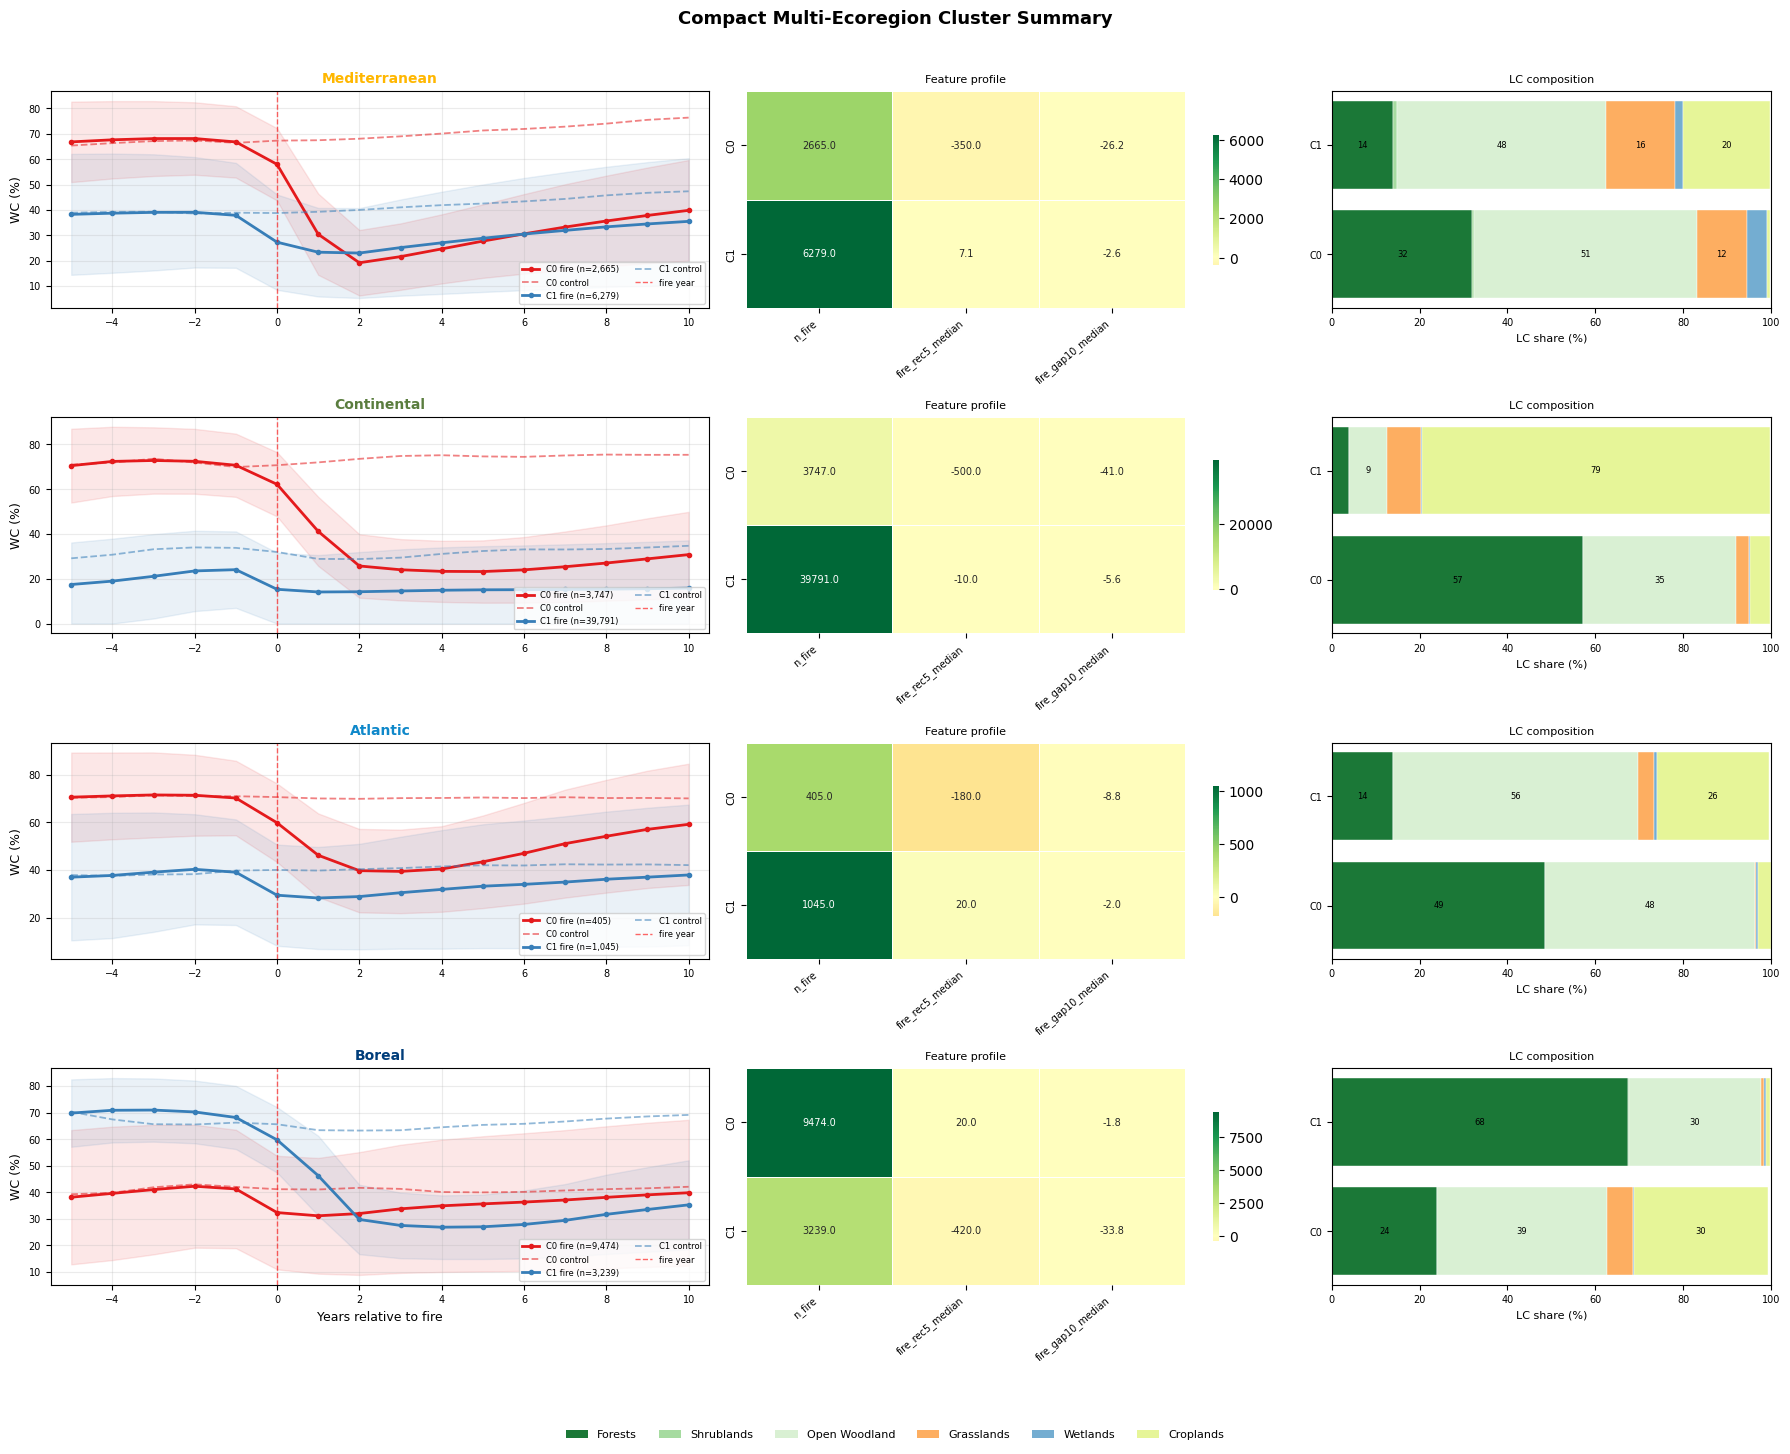

✓ Gespeichert: D:\Seafile\Meine Bibliothek\uni\master\thesis\_Runs\07_Fire_non_Fire_comparison\compact_summary.png


In [4]:
# =============================================================================
# 8b. Compact Multi-Ecoregion Summary Figure
# =============================================================================
# Layout per selected ecoregion (row):
#   Col 0 – Cluster trajectories (fire solid, control dashed)
#   Col 1 – Feature-profile heatmap (compact)  [requires .npz; fallback to stats CSV]
#   Col 2 – LC proportions stacked bar per cluster
# Requires: eco_data, df_lc, VEG_IDS, VEG_NAMES, rel_years_range  (from cell 8a)

# --- configuration ----------------------------------------------------------
SUMMARY_ECOS = ['Mediterranean', 'Continental', 'Atlantic', 'Boreal']
FEATURE_NAMES_SHORT = [
    'pre_mean', 'pre_trend', 'loss', 'loss_%',
    'rec_1yr', 'rec_3yr', 'rec_5yr', 'rec_10yr',
    'rec_rate_5yr', 'gap_10yr']
LC_COLORS = {
    'Forests':       '#1b7837',
    'Shrublands':    '#a6dba0',
    'Open Woodland': '#d9f0d3',
    'Grasslands':    '#fdae61',
    'Wetlands':      '#74add1',
    'Croplands':     '#e6f598',
}

ecos_ok = [e for e in SUMMARY_ECOS if e in eco_data]
n_ecos  = len(ecos_ok)
n_cols  = 3    # always: trajectories | heatmap | LC bar

fig, axes = plt.subplots(n_ecos, n_cols,
    figsize=(18, 3.6 * n_ecos),
    gridspec_kw={'width_ratios': [3, 2.5, 2]})
if n_ecos == 1:
    axes = axes[np.newaxis, :]

CLUSTER_COLORS = plt.cm.Set1(np.linspace(0, 1, 8))

for row_i, eco_code in enumerate(ecos_ok):
    ed     = eco_data[eco_code]
    k      = ed['chosen_k']
    npz    = ed.get('npz')
    colors = CLUSTER_COLORS[:k]

    # ── Col 0: Trajectories (fire ━ + control ┄) ───────────────────────
    ax = axes[row_i, 0]
    for cl in range(k):
        mf, sf, nf = ed['traj_fire'][cl]
        mc, sc, nc = ed['traj_ctrl'][cl]
        ax.plot(rel_years_range, mf, '-o', color=colors[cl], lw=2, ms=3,
                label=f'C{cl} fire (n={nf:,})')
        ax.fill_between(rel_years_range,
                        np.maximum(mf - sf, 0), np.minimum(mf + sf, 100),
                        alpha=0.10, color=colors[cl])
        ax.plot(rel_years_range, mc, '--', color=colors[cl], lw=1.3, alpha=0.55,
                label=f'C{cl} control')
    ax.axvline(0, color='red', ls='--', lw=1, alpha=0.6, label='fire year')
    ax.set_xlim(-5.5, 10.5)
    ax.set_ylabel('WC (%)', fontsize=9)
    if row_i == n_ecos - 1:
        ax.set_xlabel('Years relative to fire', fontsize=9)
    ax.set_title(eco_code, fontsize=10, fontweight='bold', color=ed['hex_color'])
    ax.legend(fontsize=6, ncol=2, loc='lower right')
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=7)

    # ── Col 1: Feature-profile heatmap ──────────────────────────────────
    ax = axes[row_i, 1]
    if npz is not None:
        feats  = npz['feats_fire_clean']
        labels = npz['cluster_labels']
        cl_means = np.array([np.nanmean(feats[labels == cl], axis=0) for cl in range(k)])
        df_cl = pd.DataFrame(cl_means,
                             index=[f'C{cl}' for cl in range(k)],
                             columns=FEATURE_NAMES_SHORT)
    elif ed['stats_df'] is not None:
        sdf = ed['stats_df']
        df_cl = sdf[['cluster', 'n_fire', 'fire_rec5_median',
                      'fire_gap10_median']].set_index('cluster')
        df_cl.index = [f'C{c}' for c in df_cl.index]
    else:
        df_cl = pd.DataFrame()

    if not df_cl.empty:
        sns.heatmap(df_cl, cmap='RdYlGn', annot=True,
                    fmt='.1f', ax=ax, linewidths=0.4, center=0,
                    cbar_kws={'shrink': 0.6}, annot_kws={'size': 7})
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=7)
        ax.tick_params(axis='y', labelsize=8)
    ax.set_title('Feature profile', fontsize=8)

    # ── Col 2: LC proportions stacked bar ───────────────────────────────
    ax = axes[row_i, 2]
    eco_lc = df_lc[df_lc['eco_code'] == eco_code].sort_values('cluster')
    if not eco_lc.empty:
        bottoms = np.zeros(k)
        for vname in VEG_NAMES:
            vals = eco_lc[f'{vname}_pct'].values
            ax.barh([f'C{c}' for c in range(k)], vals, left=bottoms,
                    color=LC_COLORS.get(vname, '#cccccc'), label=vname,
                    edgecolor='white', linewidth=0.3)
            for j, v in enumerate(vals):
                if v > 8:
                    ax.text(bottoms[j] + v / 2, j, f'{v:.0f}',
                            ha='center', va='center', fontsize=6)
            bottoms += vals
    ax.set_xlim(0, 100)
    ax.set_xlabel('LC share (%)', fontsize=8)
    ax.set_title('LC composition', fontsize=8)
    ax.tick_params(labelsize=7)

# --- shared legend for LC colors at bottom -----------------------------------
from matplotlib.patches import Patch
lc_handles = [Patch(facecolor=LC_COLORS[v], label=v) for v in VEG_NAMES]
fig.legend(handles=lc_handles, loc='lower center', ncol=len(VEG_NAMES),
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Compact Multi-Ecoregion Cluster Summary', fontweight='bold', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
fig_path = os.path.join(_out_base, "compact_summary.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Gespeichert: {fig_path}")